In [6]:
!ls ../data/logs-collectfailures/75rl-rtc

episode000001  episode000003  episode000005  episode000007  episode000009
episode000002  episode000004  episode000006  episode000008


In [8]:
import pandas as pd
import numpy as np
from PIL import Image
import os
import pathlib
import matplotlib.pyplot as plt
import h5py

from ipywidgets import interact

In [175]:
# "Database" of est. point of contact.
summary = {
    '../data/logs-collectfailures/75rl-rtc/episode000006/': (54.2, True),
    '../data/logs-collectfailures/75rl-rtc/episode000008': (51.7, True),
    '../data/ethernet_plugin_unplug/episode000001/': (23.4, True),
    '../data/logs-collectfailures/75rl-rtc/episode000004/': (68.95, False),
    '../data/logs-collectfailures/75rl-rtc/episode000002/': (83.45, False),
    '../data/logs-collectfailures/75rl-rtc/episode000003/': (79.55, False),
    '../data/logs-collectfailures/75rl-rtc/episode000005/': (78.6, False),
    '../data/logs-collectfailures/75rl-rtc/episode000007': (90.7, False),
    '../data/logs-collectfailures/75rl-rtc/episode000009': (56.9, False),
}

In [231]:
# basedir = pathlib.Path('../data/logs-collectfailures/75rl-rtc/episode000009')
basedir = pathlib.Path('../data/ethernet_plugin_unplug/episode000015/')
with h5py.File(basedir / 'rawdata.h5', 'r') as f:
    print(f['robot_obs'].keys())
    print(f['gripper_obs'].keys())
    actual_force = np.array(f['robot_obs/actual_force'])
    fts = np.array(f['robot_obs/time'])

    nim = len(f['camera_obs/image_bgr'])
    its = np.array(f['camera_obs/time'])

print(actual_force[0])

<KeysViewHDF5 ['actual_force', 'actual_pose', 'time']>
<KeysViewHDF5 ['gripper_force', 'gripper_width', 'time']>
[  2.64300433   6.1819247  -18.63066062   0.03318927   0.03555319
  -0.14835027]


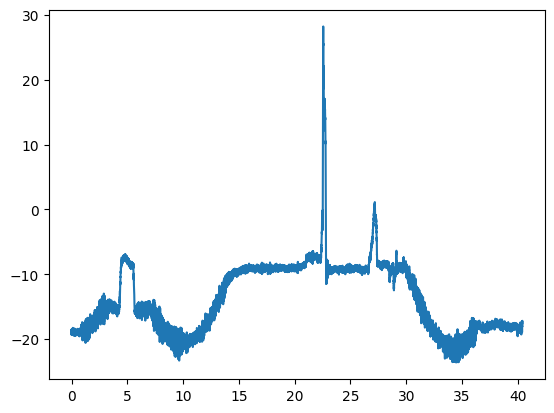

In [232]:
plt.plot(fts, actual_force[:, 2])

In [196]:
times = (80, 90)
lims = (
    np.abs(its - times[0]).argmin(),
    np.abs(its - times[1]).argmin(),
)

lims = (0, nim - 1)

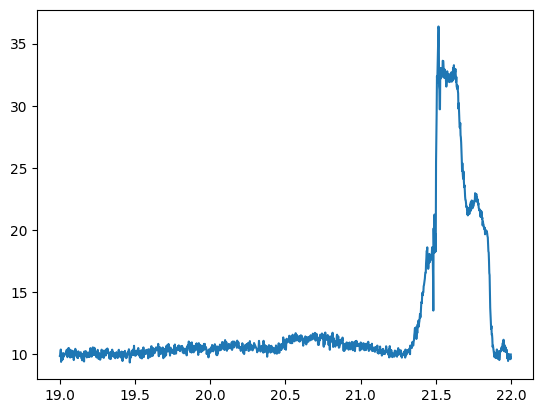

In [200]:
times = (19, 22)

sel = (times[0] < fts) & (fts < times[1])
plt.plot(fts[sel], actual_force[sel, 2] - actual_force[0, 2])

In [198]:
@interact(ix=lims)
def fun(ix):
    print(f'time = {its[ix]}')
    with h5py.File(basedir / 'rawdata.h5', 'r') as f:
        im_bgr = f['camera_obs/image_bgr'][ix]
        img = Image.fromarray(im_bgr[:,:,::-1])
    return img

interactive(children=(IntSlider(value=555, description='ix', max=1110), Output()), _dom_classes=('widget-inter…

In [177]:
left, right = -2, 8
def thingy2graph(key, val):
    t0, success = val
    pth = pathlib.Path(key)
    with h5py.File(pth / 'rawdata.h5', 'r') as f:
        actual_force = np.array(f['robot_obs/actual_force'])
        fts = np.array(f['robot_obs/time'])

    actual_force = actual_force - actual_force[0]
    sel = (t0 + left < fts) & (fts < t0 + right)
    return fts[sel] - t0, actual_force[sel, 2], success

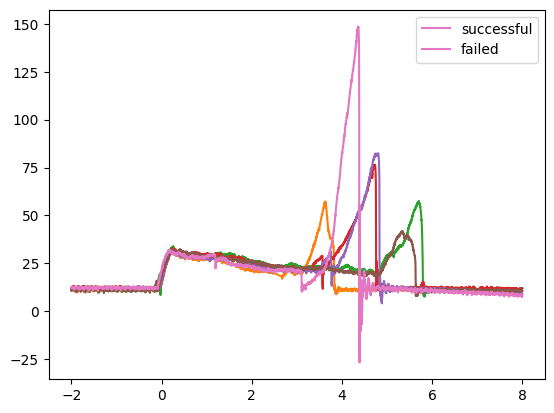

In [183]:
def yesclr():
    return 'C0'

i = 0
def noclr():
    global i
    i += 1
    return f'C{i}'

yes = None
no = None
for key, val in summary.items():
    tt, ff, bol = thingy2graph(key, val)
    if not bol:
        l, = plt.plot(tt, ff, c=yesclr() if bol else noclr())
    if bol:
        yes = l
    else:
        no = l

plt.legend([yes, no], ['successful', 'failed'])

In [179]:
import cv2

fps = 20
thumb_w, thumb_h = 240, 180   # per-tile size; match your camera's aspect ratio
border = 6

def load_episode(key, val):
    t0, success = val
    pth = pathlib.Path(key)
    with h5py.File(pth / 'rawdata.h5', 'r') as f:
        actual_force = np.array(f['robot_obs/actual_force'])
        fts = np.array(f['robot_obs/time'])
        cts = np.array(f['camera_obs/time'])
        i0, i1 = np.searchsorted(cts, [t0 + left, t0 + right])
        i0, i1 = max(i0 - 1, 0), i1 + 1        # pad one frame so the window edges have a neighbor
        imgs = f['camera_obs/image_bgr'][i0:i1]  # reads only this slice from disk
    actual_force = actual_force - actual_force[0]
    sel = (t0 + left < fts) & (fts < t0 + right)
    return {
        'rel_t': cts[i0:i1] - t0,   # camera clock, aligned with imgs
        'force_t': fts[sel] - t0,
        'force': actual_force[sel, 2],
        'imgs': imgs,
        'success': success,
    }

episodes = [load_episode(k, v) for k, v in summary.items()]

# --- static force plot, rendered once; only the cursor moves per frame ---
grid_h = 3 * (thumb_h + 2 * border)
grid_w = 3 * (thumb_w + 2 * border)
dpi = 100
fig, ax = plt.subplots(figsize=(grid_h * 1.2 / dpi, grid_h / dpi), dpi=dpi)
yes = no = None
for ep in episodes:
    l, = ax.plot(ep['force_t'], ep['force'], c='C0' if ep['success'] else 'C1')
    if ep['success']:
        yes = l
    else:
        no = l
ax.legend([yes, no], ['successful', 'failed'])
ax.set_xlim(left, right)
ax.set_xlabel('t - t0 (s)')
ax.set_ylabel('force z')
cursor = ax.axvline(left, c='r', ls='--')
fig.tight_layout()

def render_plot(tau):
    cursor.set_xdata([tau, tau])
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGR)

def render_grid(tau):
    tiles = []
    for ep in episodes:
        idx = np.abs(ep['rel_t'] - tau).argmin()   # nearest camera frame
        img = cv2.resize(ep['imgs'][idx], (thumb_w, thumb_h))
        color = (0, 255, 0) if ep['success'] else (0, 0, 255)  # BGR
        img = cv2.copyMakeBorder(img, border, border, border, border,
                                 cv2.BORDER_CONSTANT, value=color)
        tiles.append(img)
    while len(tiles) < 9:
        tiles.append(np.zeros_like(tiles[0]))
    rows = [np.hstack(tiles[i * 3:(i + 1) * 3]) for i in range(3)]
    return np.vstack(rows)

taus = np.arange(left, right, 1 / fps)
plot_w = int(render_plot(left).shape[1] * grid_h / render_plot(left).shape[0])

out = cv2.VideoWriter('grid_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (plot_w + grid_w, grid_h))
for tau in taus:
    plot_img = cv2.resize(render_plot(tau), (plot_w, grid_h))
    out.write(np.hstack([plot_img, render_grid(tau)]))
out.release()
plt.close(fig)

In [187]:
import pickle
tosave = [{k: v for k, v in ep.items() if k != 'imgs'} for ep in episodes]
pickle.dump(tosave, open('testepisodes.pkl', 'wb'))

In [193]:
def load_episode_alldata(key, val):
    t0, success = val
    pth = pathlib.Path(key)
    with h5py.File(pth / 'rawdata.h5', 'r') as f:
        actual_force = np.array(f['robot_obs/actual_force'])
        actual_pose = np.array(f['robot_obs/actual_pose'])
        fts = np.array(f['robot_obs/time'])

        grip_width = np.array(f['gripper_obs/gripper_width'])
        grip_force = np.array(f['gripper_obs/gripper_force'])
        gts = np.array(f['gripper_obs/time'])

    actual_force = actual_force - actual_force[0]
    fsel = (t0 + left < fts) & (fts < t0 + right)
    gsel = (t0 + left < gts) & (gts < t0 + right)
    return {
        'robot/time': fts[fsel] - t0,
        'robot/pose': actual_pose[fsel],
        'robot/force': actual_force[fsel],
        'grip/time': gts[gsel] - t0,
        'grip/width': grip_width[gsel],
        'grip/force': grip_force[gsel],
    }

obsdata = [load_episode_alldata(k, v) for k, v in summary.items()]

import pickle
pickle.dump(obsdata, open('testepisodes.pkl', 'wb'))